# ♟️ Introduction

**Where Pieces Fall: A Chess Kill Map** is a quick tour of where pieces tend to meet their end on the board. The goal is simple: turn a pile of games into a readable heat map of “hot” capture squares and calmer areas, so patterns jump out—common ambush points, open-file traps, and the usual pawn graveyards. It’s meant for sanity checks and curiosity: Which corners are quiet? Do certain openings funnel trades to the same tiles? Don’t overthink it; this is a high-level look at tendencies, not a perfect truth. If the patterns spark ideas, you can slice the data by time control, rating, or opening family and see what shifts.

In [1]:
!pip install python-chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 61.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=c2f8101d4f95f5824e436a594db96cd0c9fcc9b4cf56b91d4d8c5e4d19aee546
  Stored in directory: /root/.cache/pip/wheels/fb/5d/5c/59a62d8a695285e59ec9c1f66add6f8a9ac4152499a2be0113
Successfully built chess


In [2]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
import chess

In [3]:
df = pd.read_csv('/kaggle/input/chess/games.csv')
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


# General Insights
Before we get to the actual analysis, let's start with a brief overview of the data. We begin with the distribution of wins between black and white.

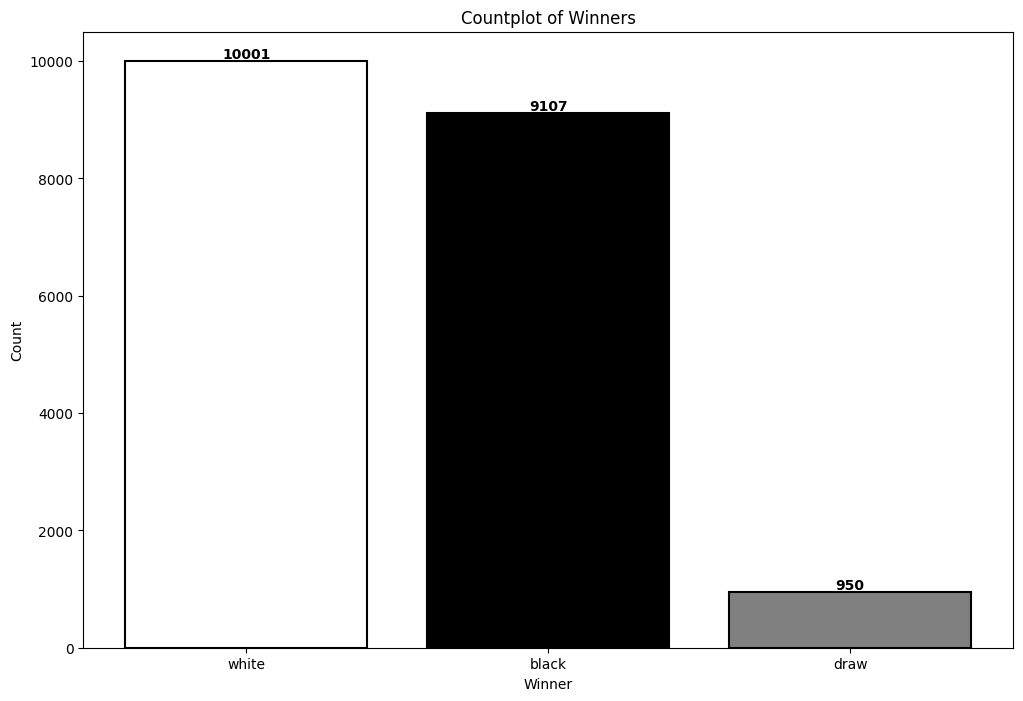

In [4]:
counts = df["winner"].value_counts()

color_map = {
    "white": "white",
    "black": "black",
    "draw": "gray"
}

plt.figure(figsize=(12, 8))

bars = plt.bar(
    counts.index,
    counts.values,
    color=[color_map[val] for val in counts.index],
    edgecolor="black",  # border
    linewidth=1.5
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

plt.xlabel("Winner")
plt.ylabel("Count")
plt.title("Countplot of Winners")
plt.show()

The plot illustrates the well-known first-move advantage in chess, which refers to White’s slightly higher winning chances due to moving first. In the dataset, White wins 10,001 games compared to Black’s 9,107, with 950 games ending in a draw. This means White secures noticeably more victories, reflecting the statistical edge conferred by the initiative of the first move, even though the game is otherwise symmetrical. Black still wins often, showing the advantage is modest rather than overwhelming, but the consistent gap highlights that moving first matters. Interestingly, the draw rate is quite low compared to professional chess, where many games end in stalemate, suggesting these results may come from faster or amateur play where decisive outcomes are more common. Overall, the chart provides clear evidence of the first-move advantage: White’s ability to dictate the game from the start translates into a small but significant winning edge.

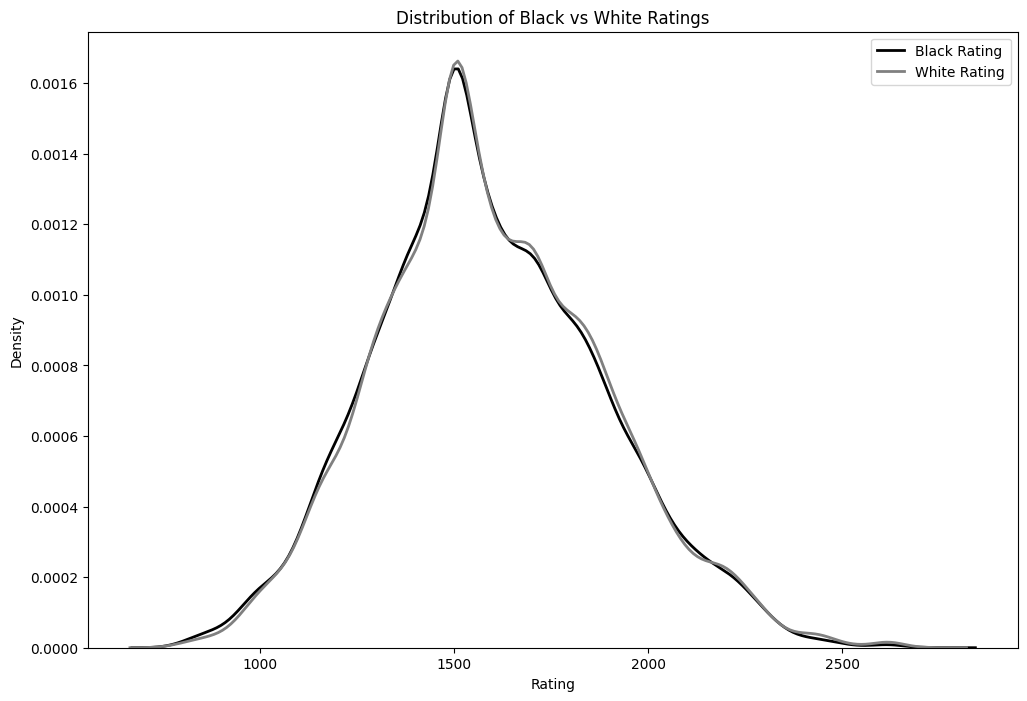

In [5]:
plt.figure(figsize=(12, 8))
sns.kdeplot(df["black_rating"], color="black", label="Black Rating", linewidth=2)
sns.kdeplot(df["white_rating"], color="gray", label="White Rating", linewidth=2)

plt.xlabel("Rating")
plt.ylabel("Density")
plt.title("Distribution of Black vs White Ratings")
plt.legend()
plt.show()

This distribution plot compares the Elo ratings of players when they play as White versus when they play as Black. Both curves follow a very similar bell-shaped pattern, peaking around the 1500 rating range, which suggests that the dataset mainly consists of players in the intermediate level. The nearly identical shapes of the two distributions indicate that there is no significant rating imbalance between players assigned White and those assigned Black—meaning the assignment of color is effectively random and does not favor one group of players over the other in terms of strength. Minor deviations between the two lines are visible, but they are small and do not point to any systematic difference.

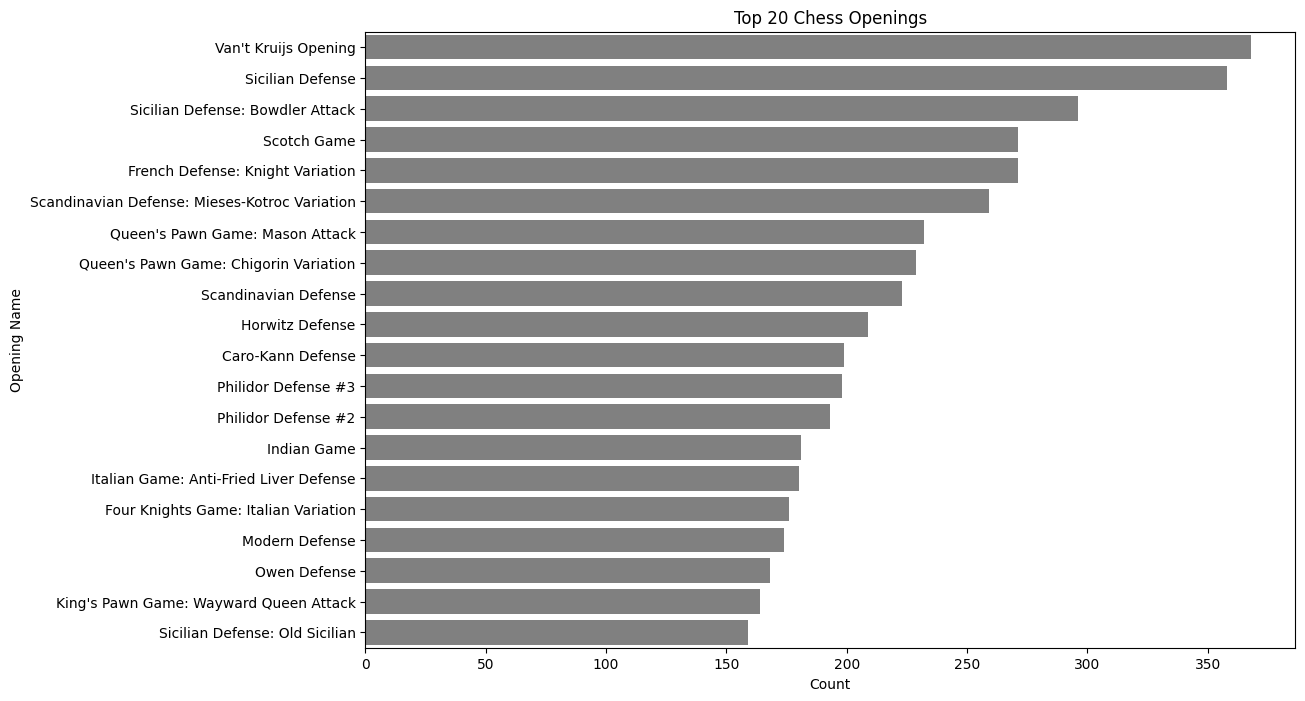

In [6]:
top_openings = df["opening_name"].value_counts().nlargest(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_openings.values,
    y=top_openings.index,
    color="gray"
)

plt.xlabel("Count")
plt.ylabel("Opening Name")
plt.title("Top 20 Chess Openings")
plt.show()

The bar chart shows the 20 most frequently played chess openings in your dataset. At the top, we see Van’t Kruijs Opening and the Sicilian Defense dominating the list, with over 350 occurrences each, followed by other well-known systems such as the Scotch Game, French Defense, and Scandinavian Defense. The counts gradually decrease as we move down the ranking, but all of the listed openings represent popular choices among players, highlighting a mix of aggressive attacking systems and solid defensive setups.

## Common Patterns in the Openings

When we examine the list more closely, several similarities stand out:

1. **Central Control as a Core Theme**
Almost all these openings revolve around the fight for the central squares (e4, d4, e5, d5). Whether it is White pushing a pawn to e4 (Sicilian Defense, Scotch Game, Italian Game) or d4 (Queen’s Pawn Game, Indian Game), or Black responding with c5 (Sicilian Defense) or d5 (Scandinavian Defense, French Defense), the central pawn push is the foundation of most strategies. The central struggle determines early space control and piece activity.

2. **Knights as the First Developed Pieces**
A strong similarity among many openings—both for White and Black—is the early development of knights. In the Scotch Game, Italian Game, Four Knights Game, and Caro-Kann Defense, knights are usually brought to f3/c3 (for White) or f6/c6 (for Black) within the first few moves. Knights are often developed before bishops because they directly contest central squares.

3. **Pawn Structures Defining Each Opening**

    - **e4 pawn openings (Open Games):** Sicilian Defense, Scotch Game, Italian Game, and Philidor Defense all start from White’s 1. e4 move. These lead to sharp tactical battles or solid structures depending on the response.

    - **d4 pawn openings (Closed Games):** Queen’s Pawn variations and the Indian Game stem from 1. d4, generally producing slower, more strategic middlegames.

    - **Unusual pawn pushes:** Some rare openings like Van’t Kruijs (1. e3) are less central but still flexible, often aiming for transpositions.

4. **Defensive Systems for Black**
Several of the listed openings are Black’s responses to 1. e4 or 1. d4: Sicilian, Caro-Kann, French, Scandinavian, and Philidor. These reflect Black’s main repertoire of defenses—some (like the Sicilian) being counter-attacking and asymmetrical, while others (like the Caro-Kann or French) are solid and defensive in nature.


## Pieces Affected in the Early Game

Across these openings, the same pieces tend to be activated first:
- **Pawns:** Central pawns (e- and d-pawns) are nearly always the first to move, shaping the character of the opening. Black frequently challenges with c- or d-pawns (Sicilian, French, Scandinavian).
- **Knights:** Almost universally developed early, knights go to f3/c3 for White and f6/c6 for Black, immediately supporting central pawn play.
- **Bishops:** Their development depends on pawn structure. For example, in the Italian Game and Scotch, White’s light-squared bishop comes to c4 early; in the French Defense, Black’s dark-squared bishop is often locked in, which becomes a thematic issue.


We will keep this in mind for later when we build the heat map showing the positions in which the pieces are most frequently captured. Before that, however, we need to briefly discuss **SAN notation**. 

# Algebraic (SAN) Notation

The important column is `moves` which contains the typical abbreviation for moving the pieces. Hard to understand? Let´s break it down. I assume that you are familiar with the rules of chess, so I will not explain them separately. Let´s have a look at the first first game where bourgris played as white against a-00. This notation is called the **algebraic (SAN) notation**. Let´s break it down. 

**Board Squares**
- Files a-h (columns) and ranks 1-8 (rows). A square like **d4** is file **d**, rank **4**.

**Piece Letters**
- K = King
- Q = Queen
- R = Rook
- B = Bishop
- N = Knight (because K is taken)
- Pawn = no letter (just the square, e.g., e4)

**Core move symbols**

- **Piece move:** Nf3, Bb4 → piece letter + destination square.
- **Pawn move:** e4 → just the square (since pawns have no letter).
- **Capture:** add x → Bxa6, cxd5 (a c-file pawn captured something on d5).
- **Check:** + → Bb4+.
- **Checkmate:** # → Qh7#.
- **Castling:** O-O (king-side), O-O-O (queen-side).
- **Promotion:** e8=Q, or with a capture exd8=N+ (promotes to a knight and gives check).
- **En passant:** often written exd6 e.p. (the e.p. tag is optional in practice).

**Disambiguation (when two same pieces could go to the same square)**
- Add the origin file: Nbd2 (the knight from the b-file goes to d2)
- Or the origin rank: N1f3
- Or both if needed: Nb1d2

**Move numbers, ellipses, results, and comments**
- Move numbers: 12. (White’s move 12), 12... (Black’s move 12).
- Ellipses ... in a score mean “it’s Black to move in this line.”
- Game result: 1-0 (White wins), 0-1 (Black wins), 1/2-1/2 or ½–½ (draw), * (no result).
- Annotations (optional): ! good move, !! brilliant, ? mistake, ?? blunder, !? interesting, ?! dubious.

So in our example the notation means:

- d4/d5: pawn pushes.
- c4: White pawn to c4.
- c6: Black pawn to c6.
- cxd5: the c-pawn captures on d5.
- e6: Black pawn to e6.
- dxe6: White pawn from d5 captures on e6.
- fxe6: Black f-pawn recaptures on e6.
- Nf3: knight to f3.
- Bb4+: bishop to b4 giving check.
- Nc3: knight to c3.
- Ba5: bishop to a5.

# Kill Map
We have a good overview of the data. We know what SAN notation is. Now let's move on to the actual part of this notebook: a heat map showing the dangerous positions in a chess game. 

In [7]:
# Helper
FILES = "abcdefgh"
RANKS = "12345678"

In [8]:
def sq_to_rc(sq: int):
    """
    Convert a python-chess square index (0–63) into row/column coordinates.

    In python-chess, squares are encoded as integers:
        - 0 = a1, 1 = b1, ..., 7 = h1
        - 8 = a2, ..., 63 = h8

    This helper returns coordinates suitable for 2D array indexing,
    where the first index is the rank (row, 0–7 from bottom to top)
    and the second index is the file (column, 0–7 from left to right).

    Args:
        sq (int): Square index from 0 to 63, as used by python-chess.

    Returns:
        tuple[int, int]: (row, col) where
            - row = rank index, 0 for rank 1 up to 7 for rank 8
            - col = file index, 0 for file 'a' up to 7 for file 'h'

    Example:
        >>> import chess
        >>> sq_to_rc(chess.E4)
        (3, 4)  # row 3 = rank 4, col 4 = file 'e'
    """
    f = chess.square_file(sq)
    r = chess.square_rank(sq)
    return r, f  # row = rank, col = file

In [9]:
def init_instance_labels():
    """
    Create a mapping from starting squares to stable piece instance labels.

    This initializes a standard chess board using python-chess and assigns
    each starting piece a unique identifier of the form:
        '<side><piece>_<square>'
    where:
        - side = 'w' for White, 'b' for Black
        - piece = one-letter uppercase symbol (P, N, B, R, Q, K)
        - square = algebraic square name (e.g. 'a2', 'e1')

    Example labels:
        - "wP_a2" for the White pawn on a2
        - "bN_g8" for the Black knight on g8
        - "wK_e1" for the White king on e1

    Returns:
        dict[int, str]: Mapping from square indices (0–63) to
        instance labels as strings.
    """
    b = chess.Board()
    labels = {}
    for sq, pc in b.piece_map().items():
        side = "w" if pc.color == chess.WHITE else "b"
        labels[sq] = f"{side}{pc.symbol().upper()}_{chess.square_name(sq)}"
    return labels

In [10]:
# Initialize heatmaps
by_instance = {lbl: np.zeros((8,8), dtype=int) for lbl in init_instance_labels().values()}
by_type = {side: {t: np.zeros((8,8), dtype=int) for t in "PNBRQK"} for side in ("w","b")}

INIT_LABELS = init_instance_labels()

In [11]:
def record_capture(square: int, victim: chess.Piece, active_map: dict):
    """
    Record a capture event in the heatmaps.

    Updates both the per-piece-type (`by_type`) and per-piece-instance 
    (`by_instance`) heatmaps when a piece is captured on a given square.

    Args:
        square (int): The board square (0–63) where the capture occurred,
            as used by python-chess.
        victim (chess.Piece): The piece that was captured.
        active_map (dict[int, str]): Mapping from square indices to the 
            current instance labels (e.g., "wP_a2"). Used to update the 
            correct per-instance heatmap.

    Side Effects:
        - Increments the corresponding entry in `by_type[side][piece]` 
          for the captured piece's side and type at (row, col).
        - If an instance label exists for the captured piece in `active_map`, 
          increments the entry in `by_instance[label]` at (row, col).

    Example:
        >>> board = chess.Board()
        >>> move = chess.Move.from_uci("e2e4")
        >>> board.push(move)
        >>> record_capture(chess.E7, chess.Piece(chess.PAWN, chess.BLACK), INIT_LABELS)
        # This would increment heatmaps for a black pawn captured on e7.
    """
    r, c = sq_to_rc(square)
    side = "w" if victim.color == chess.WHITE else "b"
    t = victim.symbol().upper()
    by_type[side][t][r, c] += 1
    # Instance (which exact piece)
    lbl = active_map.get(square)
    if lbl is not None:
        by_instance[lbl][r, c] += 1

In [12]:
def consume_game(tokens):
    b = chess.Board()
    # track current square -> instance label
    sq2lbl = {sq: INIT_LABELS[sq] for sq in b.piece_map().keys()}

    for tok in tokens:
        if tok in {"1-0", "0-1", "1/2-1/2", "*"}:
            break
        if re.match(r"^[A-E][0-9]{2}$", tok, re.IGNORECASE):  # skip ECO codes like D10
            continue
        try:
            mv = b.parse_san(tok)
        except Exception:
            continue

        cap_sq = None
        victim = None
        if b.is_capture(mv):
            if b.is_en_passant(mv):
                direction = -1 if b.turn == chess.WHITE else 1  # side to move BEFORE push
                cap_sq = mv.to_square + 8*direction
            else:
                cap_sq = mv.to_square
            victim = b.piece_at(cap_sq)

        # Move label for the mover
        mover_lbl = sq2lbl.pop(mv.from_square, None)

        # Update board
        b.push(mv)

        # If there was a capture, log and drop victim
        if cap_sq is not None and victim is not None:
            record_capture(cap_sq, victim, sq2lbl)
            sq2lbl.pop(cap_sq, None)  # victim removed

        # Place mover at new square
        if mover_lbl is not None:
            sq2lbl[mv.to_square] = mover_lbl

    # End: kings' final squares get one count (as in the poster)
    wk = b.king(chess.WHITE)
    bk = b.king(chess.BLACK)
    if wk is not None:
        by_instance["wK_e1"][sq_to_rc(wk)] += 1
    if bk is not None:
        by_instance["bK_e8"][sq_to_rc(bk)] += 1

In [13]:
for move_str in df["moves"]:
    toks = [t for t in re.split(r"\s+", str(move_str).strip()) if t]
    # drop move numbers like "12." or "1..."
    filtered = []
    for t in toks:
        if re.match(r"^\d+\.+$", t) or re.match(r"^\d+\.\.\.$", t) or t == "...":
            continue
        filtered.append(t)
    consume_game(filtered)

In [14]:
def draw_board_heatmap(arr, title='♟️ Where Pieces Fall', dpi=120):
    # mask zeros (never visited)
    mask = (arr == 0)
    data = np.ma.array(arr, mask=mask)

    # colormap where masked values appear black
    cmap = plt.get_cmap("viridis").copy()  # yellow=high, purple=low
    cmap.set_bad("black")                  # masked (zeros) -> black

    # robust vmin/vmax (ignore masked zeros); handle all-zero edge case
    if (~mask).any():
        vmin = arr[~mask].min()
        vmax = arr[~mask].max()
    else:
        vmin, vmax = 0, 1  # arbitrary range to keep colorbar functional

    fig, ax = plt.subplots(figsize=(3,3), dpi=dpi)
    im = ax.imshow(
        data,
        origin="lower",
        interpolation="nearest",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(range(8)); ax.set_xticklabels(list(FILES))
    ax.set_yticks(range(8)); ax.set_yticklabels(list(RANKS))
    ax.set_xticks([x-0.5 for x in range(9)], minor=True)
    ax.set_yticks([y-0.5 for y in range(9)], minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)
    if title:
        ax.set_title(title, fontsize=10, pad=4)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    fig.tight_layout(pad=0.2)

    # keep your current return type (PIL.Image)
    import io
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

In [15]:
order = [
    "bR_a8","bN_b8","bB_c8","bQ_d8","bK_e8","bB_f8","bN_g8","bR_h8",
] + [f"bP_{f}7" for f in FILES] + [f"wP_{f}2" for f in FILES] + [
    "wR_a1","wN_b1","wB_c1","wQ_d1","wK_e1","wB_f1","wN_g1","wR_h1"
]

pretty = {"P":"pawn","N":"knight","B":"bishop","R":"rook","Q":"queen","K":"king"}

In [16]:
def nice(lbl):
    side = "white" if lbl[0]=="w" else "black"
    typ = pretty[lbl[1]]
    sq  = lbl.split("_")[1].upper()
    return f"{sq} {typ} ({side})"

In [17]:
tiles = [] 
for lbl in order: 
    arr = by_instance.get(lbl, np.zeros((8,8), dtype=int)) 
    tiles.append(draw_board_heatmap(arr, title=nice(lbl), dpi=150))

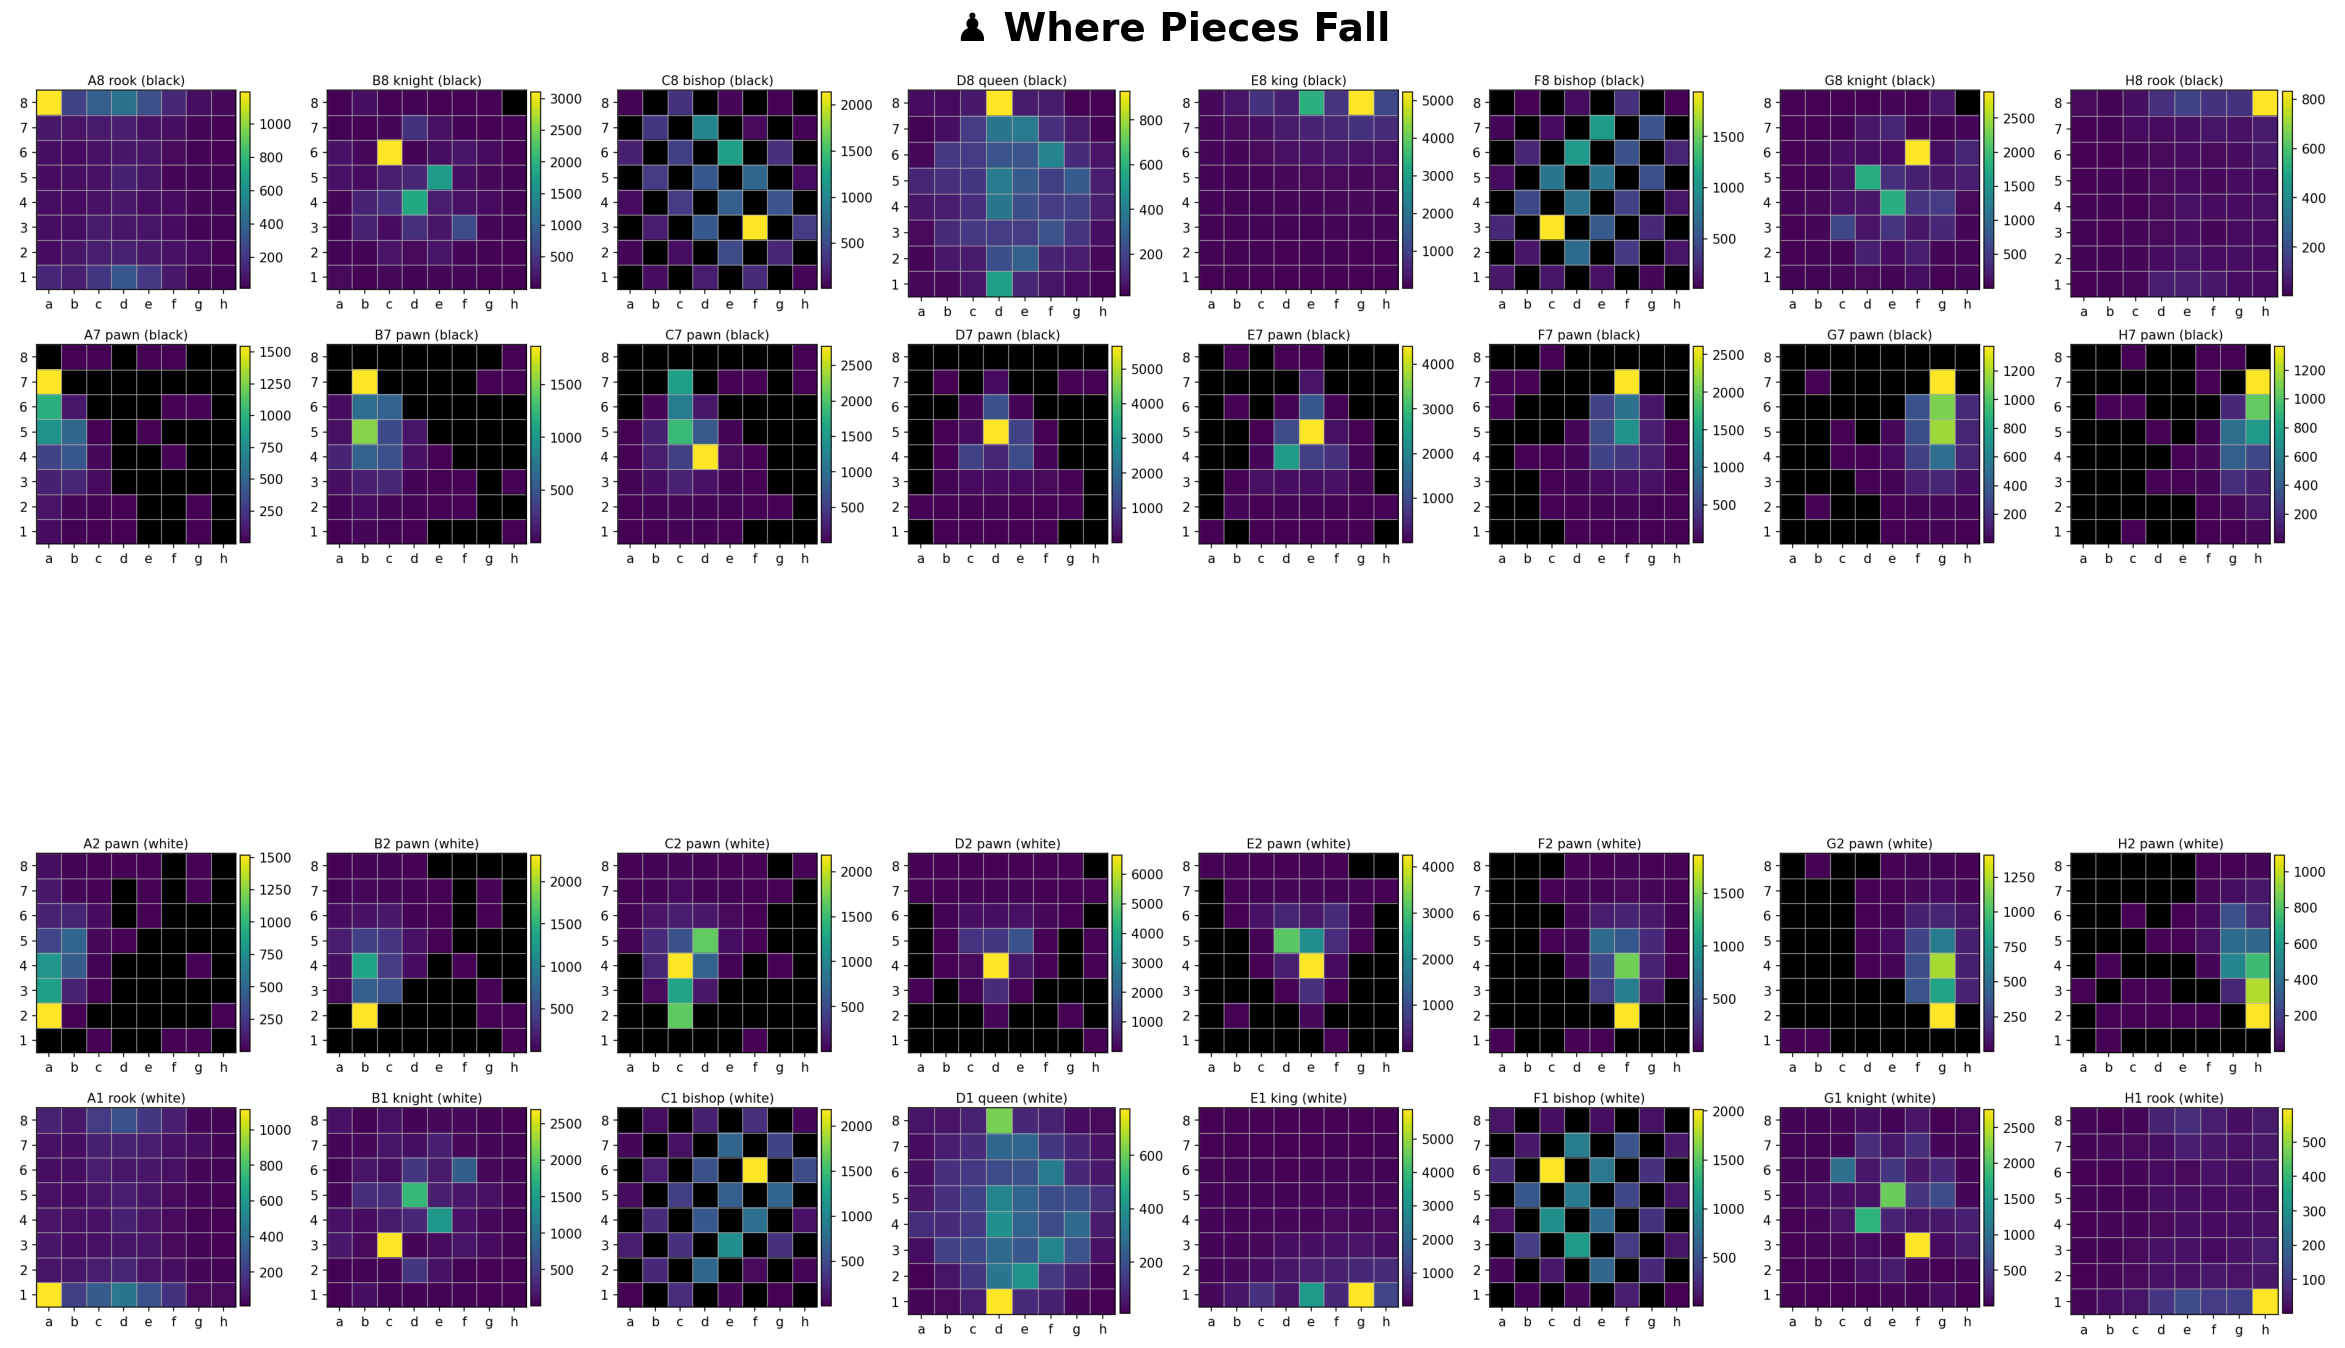

In [18]:

cols, rows = 8, 4
w, h = tiles[0].size

# add one extra row height for the divider
divider_h = h  # or e.g. h*2 for a thicker divider
canvas = Image.new("RGBA", (cols*w, rows*h + divider_h), (255, 255, 255, 255))

for i, tile in enumerate(tiles):
    r, c = divmod(i, cols)
    y_offset = r * h
    # shift rows after the first two down by divider_h
    if r >= 2:
        y_offset += divider_h
    canvas.paste(tile, (c*w, y_offset))
plt.figure(figsize=(30, 30))
plt.title("♟️ Where Pieces Fall", fontsize=28, fontweight="bold", pad=20)
plt.imshow(canvas)
plt.axis("off")
plt.show()

## General Insights from the Heatmap

This visualization shows where each piece on the chessboard most frequently ends up (or “falls”) during the course of the games in your dataset. The brighter the square, the more often a piece finishes there. The heatmaps confirm a central principle of chess: the game revolves around the center (squares e4, d4, e5, d5), while edge squares and corners are used less frequently except in specific endgames (like rooks or pawns promoting on the a/h-files). This connects well to our earlier finding that in the opening phase, **pawns and knights are the first pieces to move, shaping central control.**

## Insights by Piece
### Pawns
- Pawns show the most concentrated heat near the center (e- and d-files). This reflects the fact that central pawn pushes (e4, d4, e5, d5) are the foundation of nearly all openings.
- Side pawns (a/h-pawns) are less active but still show heat near their original files, especially in later stages (pawn storms or pushes for promotion).
- Their distributions stop at the final ranks, reflecting promotion or captures.

### Knights
- Knights’ heatmaps highlight the classic squares: c3, f3 (for White) and c6, f6 (for Black). These are the standard development squares in the opening phase.
- The “L-shaped” reach of knights is clear, with activity often clustering around the center because knights are strongest when controlling central squares.
- They rarely remain on edge squares unless repositioned in specific strategies.

### Bishops
- Bishops produce diagonal patterns, and the heatmaps clearly show their long-range influence.
- Many bishops remain on the board until later phases, hence the diagonal lines are well lit (particularly for fianchetto bishops on g2, b2, g7, b7).
- The color-sensitivity is visible: each bishop is locked to either light or dark squares, creating alternating diagonal patterns.

### Rooks
- Rooks heat up the open files (especially the central and semi-open ones like d-file, e-file, and c-file).
- The back rank (first or eighth rank) is lit up because rooks often remain there until castling and then move to central files.
- In endgames, rooks frequently dominate the seventh rank (for White) or second rank (for Black), which is a winning strategy.

### Queens
- Queens show dense concentration around the center files and ranks but also appear widely distributed because they are the most mobile piece.
 -They often move early to central squares (d3, e2, d7, e7) and later spread across the board during attacks.
- The heatmaps highlight both central activity and late-game reach.

### Kings
- Kings stay mostly near their starting files, with castling squares (g1, g8, c1, c8) lit up prominently.
- In the endgame, kings become active, explaining the shift toward central squares (e4, d4, e5, d5).
- This mirrors chess principles: safety first (castling) in the opening, then centralization in the endgame.

## Connecting to Early-Game Insights

These heatmaps reinforce the earlier point that pawns and knights dominate the opening phase. Central pawns (e- and d-files) create the structure of the game, and knights jump to c3/f3 or c6/f6 to support them. Bishops and rooks, while powerful, usually come into play later: bishops show long diagonal control after development, while rooks mostly activate once files open. The queen is highly flexible but often centralized before spreading out, while the king stays defensive until late.

# Conclusion
In this analysis, we explored several aspects of chess games, from the first-move advantage of White, to the distribution of player ratings, the most common openings, and finally the movement patterns of individual pieces. Across all visualizations, a clear theme emerges: chess is fundamentally a battle for the center of the board, with pawns and knights shaping the early game, bishops and rooks exerting influence as the middlegame unfolds, and kings stepping into action in the endgame. The opening statistics reinforced the importance of central pawn pushes and knight development, while the heatmaps vividly demonstrated how each piece finds its natural role and typical squares over the course of the game. Together, these insights highlight both the beauty and the structure of chess: a game where patterns repeat, but endless variety remains.

Thank you very much for taking the time to read through this notebook! If you found the analysis helpful or insightful, I’d really appreciate an upvote — it helps a lot and motivates me to keep sharing more work like this. ♟️😊